In [1]:
%load_ext autoreload
%autoreload 2
%config InteractiveShell.ast_node_interactivity = 'none'
%config Completer.use_jedi = False

import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Importing Necessary packages along with OffRel Utilities

In [2]:
# Imports and style
import logging
logging.basicConfig(level=logging.INFO)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt

import py_fatigue as pf
from OffRel.fatigue_load import WeibullFit, LongtermLoad
from OffRel.pf_reliability import Reliability
import pandas as pd
from scipy.stats import weibull_min

INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


# Generating Random Time Series Signal

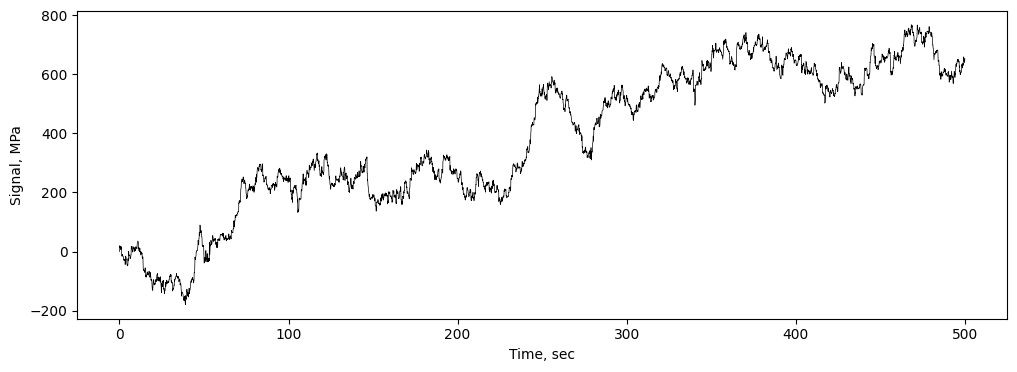

In [3]:
np.random.seed(42)

shape = 0.8      # Weibull shape parameter k
scale = 4.5      # Weibull scale parameter λ
n_cycles = 5000  # number of cycles
fs = 10          # sampling frequency in Hz
dt = 1 / fs      # time step in seconds

stress_ranges = np.random.weibull(shape, n_cycles) * scale

signal = [0.0]
for r in stress_ranges:
    direction = 1 if np.random.rand() > 0.5 else -1
    next_val = signal[-1] - direction * r
    signal.append(next_val)

signal = np.array(signal)
time = np.arange(len(signal)) * dt

plt.rcParams['figure.figsize'] = (12.0, 4.0)
plt.plot(time, signal, 'k', lw=0.5)
plt.xlabel("Time, sec")
plt.ylabel("Signal, MPa")
plt.show()

# Creating CycleCount instance and Rainflow Dictionaries to Test the Methods

In [4]:
# CycleCount definition
cycle_count = pf.CycleCount.from_timeseries(
    time=time, data=signal, range_bin_lower_bound=0.00005)

In [5]:
rf_data = cycle_count.as_dict()
df = pd.DataFrame({
    "time": time,
    "stress": signal
})

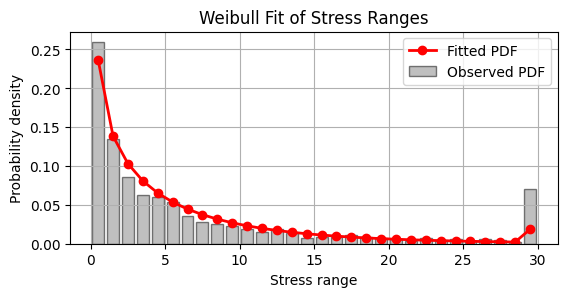

5.153151739071072


In [6]:
print(WeibullFit.from_timeseries(df, k=0.8, scale_init=5,plot="both"))


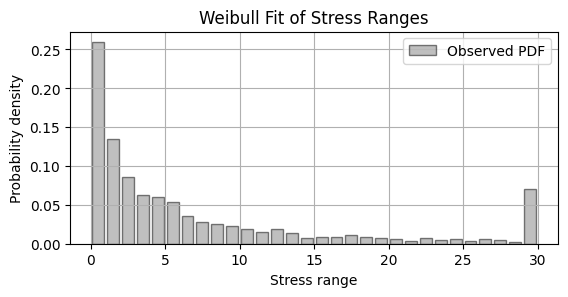

5.152928208075166


In [7]:
print(WeibullFit.from_rainflow(rf_data, k=0.8, scale_init=3, plot='observed'))

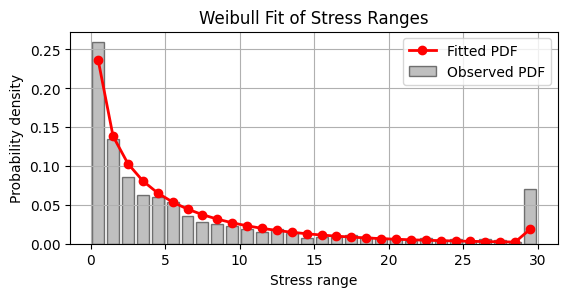

5.153916088191389


In [8]:
print(WeibullFit.from_cyclecount(cycle_count, k=0.8, scale_init=10, plot='both'))

# Defining SN Curve using py_fatigue

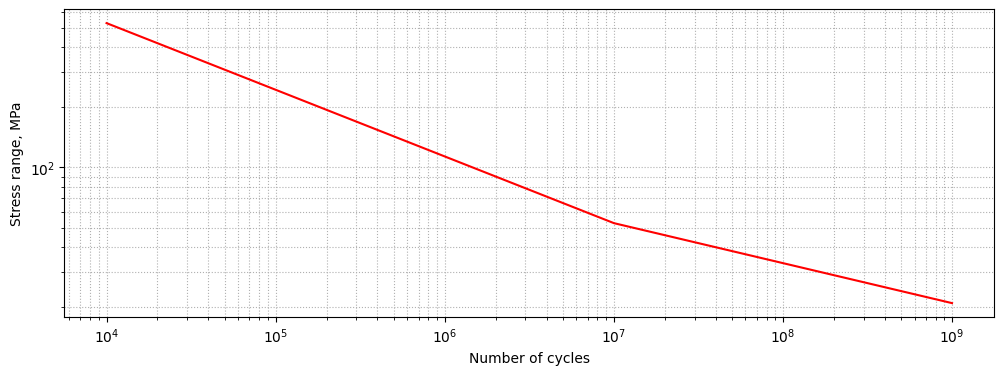

In [9]:

sn1 = pf.SNCurve(
    slope=[3, 5], 
    intercept=[12.164, 15.606],
    #N_knee=1e7,
    environment = 'Air', 
    curve = 'DNV-D-A',
    norm = 'DNVGL-RP-C203/2016',
    color='r'
)
sn1.plot()

# Solving for Weibull Scale Parameter using LongtermLoad.from_design_to_the_limit

In [10]:
config = {                                                                                                                                                                                                
      "sn": sn1,
      "t_years": 20,                                                                                                                                                                                                                   
      "fdf": 3,
      "mean_period": 6.25,  
  }
ltl = LongtermLoad(**config)
print("Weibull scale parameter (q):", ltl.from_design_to_the_limit())


Weibull scale parameter (q): 7.506534162478012


# Calculating Fatigue Damage using LongtermLoad

In [11]:

n_cycles = ltl.t_years * 3600 * 24 * 365 / ltl.mean_period
print(ltl.fatigue_damage_weibull(n_cycles=n_cycles, q=7.5066, h=0.8))

0.33334421038133133


# Testing `LongtermLoad.from_dlc_simulations` with Synthetic DLC Data

Three load cases with exponentially-decaying rainflow cycle counts (mimicking time-domain simulation output) and occurrence probabilities summing to 1.

In [12]:
# Shared bin grid (same for all DLCs — required by _build_long_term_pdf)
bin_edges = np.arange(0, 31, 1, dtype=float)   # 30 bins, 0–30 MPa
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
stress_idx = np.arange(30)

# Synthetic rainflow-style counts: exponential decay mimicking simulation output
# Harsher sea state → heavier tail (slower decay)
rng = np.random.default_rng(42)
dlc_defs = [
    ("DLC1.2", 0.50, np.round(8000 * np.exp(-stress_idx / 3.0) + rng.integers(0, 20, 30)).astype(float)),
    ("DLC1.3", 0.30, np.round(5000 * np.exp(-stress_idx / 6.0) + rng.integers(0, 15, 30)).astype(float)),
    ("DLC2.1", 0.20, np.round(3000 * np.exp(-stress_idx / 9.0) + rng.integers(0, 10, 30)).astype(float)),
]

rows = []
for dlc_id, prob, counts in dlc_defs:
    rows.append({"dlc_id": dlc_id, "probability": prob,
                 "seed_id": 0, "bin_edges": bin_edges, "counts": counts})

dlc_data = pd.DataFrame(rows)
print(dlc_data)

   dlc_id  probability  seed_id  \
0  DLC1.2          0.5        0   
1  DLC1.3          0.3        0   
2  DLC2.1          0.2        0   

                                           bin_edges  \
0  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...   
1  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...   
2  [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...   

                                              counts  
0  [8001.0, 5747.0, 4120.0, 2951.0, 2117.0, 1528....  
1  [5006.0, 4235.0, 3584.0, 3041.0, 2580.0, 2173....  
2  [3009.0, 2692.0, 2405.0, 2159.0, 1928.0, 1724....  


In [13]:
q_est = ltl.from_dlc_simulations(dlc_data)
print(f"Estimated Weibull scale parameter  q = {q_est:.4f} MPa")

Estimated Weibull scale parameter  q = 5.3993 MPa


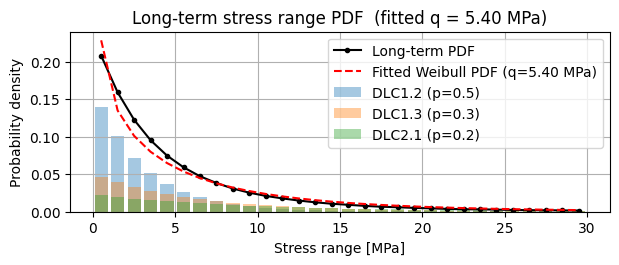

In [14]:
_, lt_pdf = ltl._build_long_term_pdf(dlc_data)

fitted_cdf = weibull_min.cdf(bin_edges, c=0.8, scale=q_est)
fitted_pdf = np.diff(fitted_cdf)

fig, ax = plt.subplots(figsize=(16/2.54, 7/2.54))
for _, row in dlc_data.iterrows():
    cnts = np.asarray(row["counts"])
    dlc_contribution = row["probability"] * cnts / cnts.sum()
    ax.bar(bin_centers, dlc_contribution, alpha=0.4, label=f'{row["dlc_id"]} (p={row["probability"]})')

ax.plot(bin_centers, lt_pdf, "k-o", lw=1.5, markersize=3, label="Long-term PDF")
ax.plot(bin_centers, fitted_pdf, "r--", lw=1.5, label=f"Fitted Weibull PDF (q={q_est:.2f} MPa)")
ax.set_xlabel("Stress range [MPa]")
ax.set_ylabel("Probability density")
ax.set_title(f"Long-term stress range PDF  (fitted q = {q_est:.2f} MPa)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Monte-Carlo Simulations for Probability of Failure

In [19]:
config = {
    "sn": sn1,
    "T": 20,
    "ncycles": n_cycles,
    "q_mean": ltl.from_design_to_the_limit(),          # from LongtermLoad
    "q_cov": 0.10,
    "h": 0.8,
    "samp": 10000,

    # S-N uncertainty
    "loga1_std": 0.2,      
    "loga2_std": 0.2,      

    # Damage model uncertainty
    "delta_mean": 0,
    "delta_cov": 0.3,

    # Optional
    "time_variant_q": False,
    "epsilonq_std": None,
}

rel = Reliability(config)

pf = rel.run_mcs(seed=123)

print("Probability of failure:", pf)

1 7.515322471481313 0.752005095470737
2 7.515322471481313 0.752005095470737
3 7.515322471481313 0.752005095470737
4 7.515322471481313 0.752005095470737
5 7.515322471481313 0.752005095470737
6 7.515322471481313 0.752005095470737
7 7.515322471481313 0.752005095470737
8 7.515322471481313 0.752005095470737
9 7.515322471481313 0.752005095470737
10 7.515322471481313 0.752005095470737
11 7.515322471481313 0.752005095470737
12 7.515322471481313 0.752005095470737
13 7.515322471481313 0.752005095470737
14 7.515322471481313 0.752005095470737
15 7.515322471481313 0.752005095470737
16 7.515322471481313 0.752005095470737
17 7.515322471481313 0.752005095470737
18 7.515322471481313 0.752005095470737
19 7.515322471481313 0.752005095470737
20 7.515322471481313 0.752005095470737
Probability of failure: [0.000e+00 9.000e-04 2.090e-02 7.950e-02 1.687e-01 2.624e-01 3.603e-01
 4.485e-01 5.302e-01 6.014e-01 6.612e-01 7.172e-01 7.620e-01 7.937e-01
 8.206e-01 8.466e-01 8.680e-01 8.844e-01 9.001e-01 9.122e-01 9.